<a href="https://colab.research.google.com/github/WVF-1/FULPs-Framework-CA-Application/blob/main/FULPs_CA_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FULPs CA — v3
**Environmental Sensitivity and Perturbation Recovery**

Author: William V. Fullerton  
Conscientiâ Research Group

---

### What changed from v2

| Component | v2 | v3 | Reason |
|-----------|----|----|--------|
| Timesteps | 100 | 150 | More time for affected states to appear post-perturbation |
| Rule perturbation | None | {2,3}→{2,3,4} survival at t=75 | Primary experimental manipulation |
| STABLE_MAX_CHANGES | 5 | 7 | Proportional scaling for 149 transitions |
| Primary metric | Convergence speed | Recovery timestep on affected states | v3 tests environmental sensitivity |
| tick() | Single rule | Accepts perturbed flag | Perturbation architecture |

### Everything preserved from v2
- IDF priors: `mu~N(0,0.02)`, `sig~U(0.05,0.30)`, `rho~U(-0.2,0.2)`
- VoidStabilizer: 9→16→9, `EA_TARGET_STD=0.3`, `EA_WEIGHT=0.5`
- `VT_WEIGHT=0.05`, `EMA_ALPHA=0.1`, `CURIOSITY_WEIGHT=2.0`, `BUFFER_DELAY=10`
- `BASE_THRESHOLD=0.70`, `CONTRA_THRESHOLD=0.60`, `CONF_GATE=0.60`
- Dynamic ARE threshold: `0.20→0.05` linear decay
- 30 runs, seeds 42–71, batch CSV every 5 runs
- VoidStabilizer trained once and reused

### Perturbation definition
At t=75, the GoL survival rule expands from {2,3} to {2,3,4} live neighbours.
Exactly **70 of 512** neighbourhood states are affected: all states where
`own=1` and `nbrs=4`. Pre-perturbation truth for these: death (0).
Post-perturbation truth: survival (1). Birth rule is unchanged.

### FULPs advantage mechanism
1. ARE pos/neg buffers are built on pre-perturbation representations.
2. Post-perturbation, cells observing 4-neighbour states find their learned
   predictions (death) contradicted by new outcomes (survival).
3. ARE contradiction rate spikes — cells that were in the neg buffer for
   4-neighbour states now produce survival, violating prior belief.
4. Curiosity weight (2.0) amplifies table updates for those contradicted cells.
5. Baseline has no contradiction signal — uniform weight on all observations.

### Hypotheses
- **A**: FULPs cells show a measurably higher contradiction rate in the 10
  timesteps immediately post-perturbation vs pre-perturbation baseline.
- **B**: FULPs cells recover correct predictions on affected states faster
  than baseline cells (lower mean recovery timestep).
- **C (v2 retained)**: Unstable cells observe more affected states and dominate
  recovery statistics; FULPs attenuates accuracy penalty in those cells.

### Key paper note (for write-up)
The consistently negative ARE margin in v2/v3 reflects GoL's inherent death
bias — 72.7% of neighbourhood states produce death — and confirms the ARE is
accurately encoding the asymmetric structure of the rule space, not converging
to a spurious representation.

### What to watch for in single run
1. Pre-perturbation accuracy on affected states high (correctly predicting death)
2. Sharp accuracy drop on affected states at t=75
3. FULPs contradiction rate spikes post-perturbation (before baseline can respond)
4. FULPs recovery curve on affected states rises faster than baseline
5. FULPs mean recovery timestep < baseline mean recovery timestep
6. VT signal stable across all 150 timesteps
7. DSC mean shifts gradually post-perturbation (population dynamics changing)

In [1]:
# ── Cell 1: Install ──────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scipy', '--quiet'])
print('Done.')

Done.


In [2]:
# ── Cell 2: Imports and Configuration ────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.linalg import cholesky
from scipy import stats

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

# ── Grid ──────────────────────────────────────────────────────────────────────
GRID_H       = 50
GRID_W       = 50
N_TIMESTEPS  = 150     # v3: extended from 100
T_PERTURB    = 75      # v3: rule change at this timestep

# ── Neighbourhood ─────────────────────────────────────────────────────────────
NBR_DIM      = 9
N_STATES     = 512

# ── VoidStabilizer (preserved from v4/v1/v2) ──────────────────────────────────
VOID_HIDDEN   = 16
EA_TARGET_STD = 0.3
EA_WEIGHT     = 0.5
VOID_EPOCHS   = 100
VOID_BATCH    = 256

# ── Void Tether (preserved) ───────────────────────────────────────────────────
VT_WEIGHT     = 0.05

# ── ARE (preserved from v2; CONF_GATE=0.60 ablation-confirmed) ────────────────
CONTRA_START     = 0.20
CONTRA_END       = 0.05
CONF_GATE        = 0.60
BUFFER_DELAY     = 10
EMA_ALPHA        = 0.1
CURIOSITY_WEIGHT = 2.0

# ── Prediction thresholds (ablation-confirmed from v1) ────────────────────────
BASE_THRESHOLD   = 0.70
CONTRA_THRESHOLD = 0.60

# ── Stability (v3: scaled for 149 transitions) ────────────────────────────────
STABLE_MAX_CHANGES = 7     # ~5% change rate over 149 transitions

# ── Multi-run ─────────────────────────────────────────────────────────────────
N_RUNS     = 30
BATCH_SIZE = 5
BASE_SEED  = 42
OUT_DIR    = '/content'

# ── Contradiction spike windows (relative to T_PERTURB) ───────────────────────
SPIKE_PRE_START  = T_PERTURB - 10   # 65
SPIKE_PRE_END    = T_PERTURB        # 74 (exclusive)
SPIKE_POST_START = T_PERTURB + 1    # 76
SPIKE_POST_END   = T_PERTURB + 11   # 85 (exclusive)

# ── Derived ───────────────────────────────────────────────────────────────────
REP_DIM = VOID_HIDDEN

print('Configuration ready.')
print(f'  Grid: {GRID_H}x{GRID_W}  |  Timesteps: {N_TIMESTEPS}  |  T_PERTURB: {T_PERTURB}')
print(f'  Perturbation: survival {{2,3}} -> {{2,3,4}} at t={T_PERTURB}')
print(f'  VOID_HIDDEN={VOID_HIDDEN}  EA_target_std={EA_TARGET_STD}  lambda_EA={EA_WEIGHT}')
print(f'  lambda_VT={VT_WEIGHT}')
print(f'  ARE: threshold {CONTRA_START}->{CONTRA_END}  CONF_GATE={CONF_GATE}  '
      f'buffer_delay={BUFFER_DELAY}  curiosity={CURIOSITY_WEIGHT}')
print(f'  BASE_THRESHOLD={BASE_THRESHOLD}  CONTRA_THRESHOLD={CONTRA_THRESHOLD}')
print(f'  STABLE_MAX_CHANGES={STABLE_MAX_CHANGES}')
print(f'  Multi-run: {N_RUNS} runs, batch checkpoint every {BATCH_SIZE}')

Configuration ready.
  Grid: 50x50  |  Timesteps: 150  |  T_PERTURB: 75
  Perturbation: survival {2,3} -> {2,3,4} at t=75
  VOID_HIDDEN=16  EA_target_std=0.3  lambda_EA=0.5
  lambda_VT=0.05
  ARE: threshold 0.2->0.05  CONF_GATE=0.6  buffer_delay=10  curiosity=2.0
  BASE_THRESHOLD=0.7  CONTRA_THRESHOLD=0.6
  STABLE_MAX_CHANGES=7
  Multi-run: 30 runs, batch checkpoint every 5


In [3]:
# ── Cell 3: Conway's Game of Life (perturbed variant added) ───────────────────
def tick(grid, perturbed=False):
    """
    Single GoL step on a toroidal grid.
    perturbed=False: standard survival {2,3} neighbours.
    perturbed=True : expanded survival {2,3,4} neighbours.
    Birth rule (exactly 3 live neighbours) is unchanged in both variants.

    The perturbation affects exactly 70 of 512 neighbourhood states:
    all states where own=1 and nbrs=4, flipping death->survival.
    """
    H, W = grid.shape
    nbr_count = np.zeros((H, W), dtype=np.int8)
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0:
                continue
            nbr_count += np.roll(np.roll(grid, di, axis=0), dj, axis=1)
    next_grid = np.zeros((H, W), dtype=np.int8)
    alive = grid == 1
    if perturbed:
        # Survival on {2, 3, 4} neighbours
        next_grid[alive  & ((nbr_count == 2) | (nbr_count == 3) | (nbr_count == 4))] = 1
    else:
        # Standard survival on {2, 3} neighbours
        next_grid[alive  & ((nbr_count == 2) | (nbr_count == 3))] = 1
    next_grid[~alive & (nbr_count == 3)] = 1
    return next_grid


def population(grid):
    return int(grid.sum())


# Sanity checks
_test = np.zeros((10, 10), dtype=np.int8)
_test[1,2]=_test[2,3]=_test[3,1]=_test[3,2]=_test[3,3] = 1
assert population(tick(_test, perturbed=False)) == 5, 'GoL glider failed'

# A live cell with 4 neighbours should die in original, survive in perturbed
_test2 = np.zeros((5, 5), dtype=np.int8)
_test2[2,2] = 1    # center alive
_test2[1,2] = _test2[3,2] = _test2[2,1] = _test2[2,3] = 1  # 4 live neighbours
_standard  = tick(_test2, perturbed=False)[2, 2]
_perturbed = tick(_test2, perturbed=True)[2, 2]
assert _standard == 0 and _perturbed == 1, 'Perturbation rule check failed'

print("Conway's Game of Life defined (toroidal, perturbed variant).")
print(f'  Glider: PASS')
print(f'  4-neighbour cell: standard={_standard} (dies), perturbed={_perturbed} (survives): PASS')

Conway's Game of Life defined (toroidal, perturbed variant).
  Glider: PASS
  4-neighbour cell: standard=0 (dies), perturbed=1 (survives): PASS


In [4]:
# ── Cell 4: Inner Depth Field (unchanged from v1/v2) ─────────────────────────
class InnerDepthField:
    """
    IDF — FULP 1. 9-dimensional void generator.
    Priors preserved exactly from v4: mu~N(0,0.02), sig~U(0.05,0.30), rho~U(-0.2,0.2).
    """
    def __init__(self, seq_len=NBR_DIM):
        self.seq_len = seq_len

    def _corr_matrix(self, rho):
        idx = np.arange(self.seq_len)
        C   = rho ** np.abs(idx[:, None] - idx[None, :])
        return C + np.eye(self.seq_len) * 1e-6

    def sample(self, n):
        X = np.zeros((n, self.seq_len))
        for i in range(n):
            mu  = np.random.normal(0, 0.02)
            sig = np.random.uniform(0.05, 0.30)
            rho = np.random.uniform(-0.2, 0.2)
            try:
                L    = cholesky(self._corr_matrix(rho), lower=True)
                X[i] = mu + sig * (L @ np.random.normal(0, 1, self.seq_len))
            except Exception:
                X[i] = np.random.normal(mu, sig, self.seq_len)
        return X

    def sample_tensor(self, n):
        return torch.FloatTensor(self.sample(n).astype(np.float32))


IDF = InnerDepthField(seq_len=NBR_DIM)
print('IDF defined. Priors: mu~N(0,0.02)  sig~U(0.05,0.30)  rho~U(-0.2,0.2)')

IDF defined. Priors: mu~N(0,0.02)  sig~U(0.05,0.30)  rho~U(-0.2,0.2)


In [5]:
# ── Cell 5: VoidStabilizer (unchanged from v1/v2) ─────────────────────────────
class VoidStabilizer(nn.Module):
    """
    VoidStabilizer — FULP 1. Architecture: 9->16->9.
    All parameters preserved from v4. EA targets activation STD.
    """
    def __init__(self, seq_len=NBR_DIM, hidden_dim=VOID_HIDDEN,
                 ea_target_std=EA_TARGET_STD, ea_weight=EA_WEIGHT):
        super().__init__()
        self.ea_target_std = ea_target_std
        self.ea_weight     = ea_weight
        self.encoder       = nn.Sequential(nn.Linear(seq_len, hidden_dim), nn.Tanh())
        self.decoder       = nn.Linear(hidden_dim, seq_len)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

    def encode(self, x):
        return self.encoder(x)

    def dsc(self, x):
        x_hat, _ = self.forward(x)
        return torch.mean((x - x_hat) ** 2, dim=1)

    def void_tether(self, idf, n=64):
        with torch.no_grad():
            x_void = idf.sample_tensor(n)
        return float(self.dsc(x_void).mean().item())

    def training_loss(self, x):
        x_hat, z   = self.forward(x)
        recon_loss = nn.MSELoss()(x_hat, x)
        ea_loss    = (z.std() - self.ea_target_std) ** 2
        total      = recon_loss + self.ea_weight * ea_loss
        return total, recon_loss.item(), ea_loss.item()


def train_void_stabilizer(void_model, idf, n_epochs=VOID_EPOCHS,
                           batch_size=VOID_BATCH, lr=1e-3, verbose=True):
    opt     = torch.optim.Adam(void_model.parameters(), lr=lr)
    history = {'total': [], 'recon': [], 'ea': []}
    for epoch in range(n_epochs):
        x_void = idf.sample_tensor(batch_size)
        total, recon, ea = void_model.training_loss(x_void)
        opt.zero_grad(); total.backward(); opt.step()
        history['total'].append(total.item())
        history['recon'].append(recon)
        history['ea'].append(ea)
        if verbose and epoch % 25 == 0:
            print(f'    [Void {epoch:3d}]  total={total.item():.4f}  '
                  f'recon={recon:.4f}  EA={ea:.4f}')
    return history


print('VoidStabilizer defined (9->16->9).')

VoidStabilizer defined (9->16->9).


STAGE 0: Void Stabilization
    [Void   0]  total=0.0740  recon=0.0705  EA=0.0070
    [Void  25]  total=0.0451  recon=0.0419  EA=0.0064
    [Void  50]  total=0.0319  recon=0.0292  EA=0.0055
    [Void  75]  total=0.0266  recon=0.0248  EA=0.0037

VoidStabilizer frozen. DSC + VT operational.
  Final recon loss : 0.0194
  Final EA loss    : 0.0023


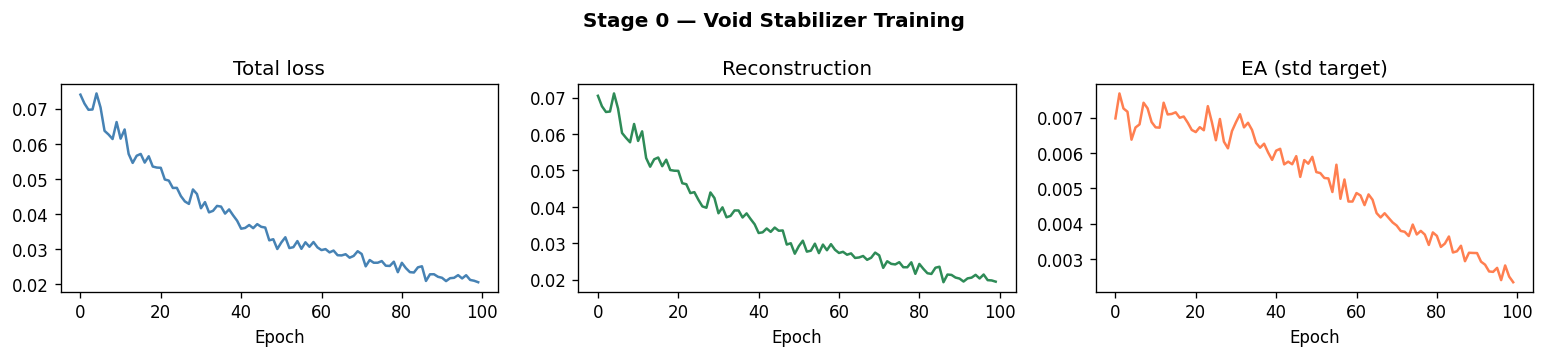

Saved: fulps_ca_v3_void_training.png


In [6]:
# ── Cell 6: Stage 0 — Void Stabilization (unchanged from v1/v2) ───────────────
print('=' * 60)
print('STAGE 0: Void Stabilization')
print('=' * 60)

torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)

void_model = VoidStabilizer(
    seq_len=NBR_DIM, hidden_dim=VOID_HIDDEN,
    ea_target_std=EA_TARGET_STD, ea_weight=EA_WEIGHT
)

void_history = train_void_stabilizer(
    void_model, IDF, n_epochs=VOID_EPOCHS, batch_size=VOID_BATCH,
    lr=1e-3, verbose=True
)

for p in void_model.parameters():
    p.requires_grad = False
void_model.eval()

print('\nVoidStabilizer frozen. DSC + VT operational.')
print(f'  Final recon loss : {void_history["recon"][-1]:.4f}')
print(f'  Final EA loss    : {void_history["ea"][-1]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
fig.suptitle('Stage 0 — Void Stabilizer Training', fontweight='bold')
for ax, key, col, lbl in zip(
    axes, ['total', 'recon', 'ea'],
    ['steelblue', 'seagreen', 'coral'],
    ['Total loss', 'Reconstruction', 'EA (std target)']
):
    ax.plot(void_history[key], color=col)
    ax.set_title(lbl); ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fulps_ca_v3_void_training.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fulps_ca_v3_void_training.png')

DSC THRESHOLD CALIBRATION
  IDF DSC   : mean=0.0199  std=0.0193
  CA  DSC   : mean=0.1291  std=0.0974
  DSC threshold (25th pct of CA) : 0.0526
  Separation: OK


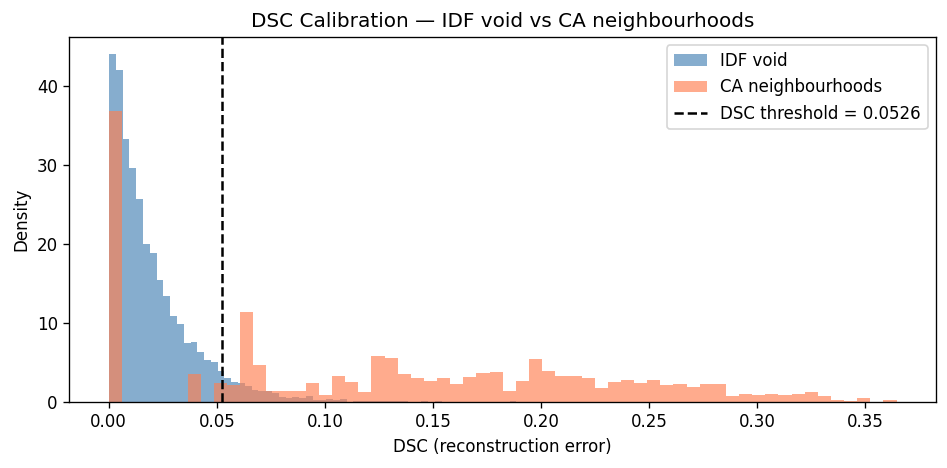

Saved: fulps_ca_v3_dsc_calibration.png


In [7]:
# ── Cell 7: DSC Threshold Calibration (unchanged from v1/v2) ─────────────────
print('=' * 60)
print('DSC THRESHOLD CALIBRATION')
print('=' * 60)

np.random.seed(0)
cal_grid = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)
all_ca_dsc = []
_shifts_cal = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,0),(0,1),(1,-1),(1,0),(1,1)]

for _ in range(5):
    channels = np.zeros((GRID_H, GRID_W, 9), dtype=np.float32)
    for k, (di, dj) in enumerate(_shifts_cal):
        channels[:, :, k] = np.roll(
            np.roll(cal_grid, -di, axis=0), -dj, axis=1
        ).astype(np.float32)
    nbr_t = torch.FloatTensor(channels.reshape(-1, NBR_DIM))
    with torch.no_grad():
        dsc_vals = void_model.dsc(nbr_t).numpy()
    all_ca_dsc.append(dsc_vals)
    cal_grid = tick(cal_grid, perturbed=False)

all_ca_dsc = np.concatenate(all_ca_dsc)
x_idf_ref  = IDF.sample_tensor(5000)
with torch.no_grad():
    idf_dsc_ref = void_model.dsc(x_idf_ref).numpy()

DSC_THRESHOLD = float(np.percentile(all_ca_dsc, 25))

print(f'  IDF DSC   : mean={idf_dsc_ref.mean():.4f}  std={idf_dsc_ref.std():.4f}')
print(f'  CA  DSC   : mean={all_ca_dsc.mean():.4f}  std={all_ca_dsc.std():.4f}')
print(f'  DSC threshold (25th pct of CA) : {DSC_THRESHOLD:.4f}')
print(f'  Separation: {"OK" if idf_dsc_ref.mean() < all_ca_dsc.mean() else "WARNING"}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(idf_dsc_ref, bins=60, alpha=0.65, color='steelblue', label='IDF void', density=True)
ax.hist(all_ca_dsc,  bins=60, alpha=0.65, color='coral',     label='CA neighbourhoods', density=True)
ax.axvline(DSC_THRESHOLD, color='black', linestyle='--', lw=1.5,
           label=f'DSC threshold = {DSC_THRESHOLD:.4f}')
ax.set_xlabel('DSC (reconstruction error)'); ax.set_ylabel('Density')
ax.set_title('DSC Calibration — IDF void vs CA neighbourhoods')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fulps_ca_v3_dsc_calibration.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fulps_ca_v3_dsc_calibration.png')

In [8]:
# ── Cell 8: Grid and Neighbourhood Utilities ──────────────────────────────────

# ── GoL truth tables (both variants) ──────────────────────────────────────────
def precompute_gol_truth(perturbed=False):
    truth = np.zeros(N_STATES, dtype=np.int8)
    for state in range(N_STATES):
        bits   = np.array([(state >> k) & 1 for k in range(9)], dtype=np.int8)
        own    = int(bits[4])
        n_nbrs = int(bits.sum()) - own
        survive_set = [2, 3, 4] if perturbed else [2, 3]
        if own == 1:
            truth[state] = 1 if n_nbrs in survive_set else 0
        else:
            truth[state] = 1 if n_nbrs == 3 else 0
    return truth


GOL_TRUTH_ORIG = precompute_gol_truth(perturbed=False)
GOL_TRUTH_PERT = precompute_gol_truth(perturbed=True)

# AFFECTED_STATES: states where truth changes under perturbation
AFFECTED_MASK   = (GOL_TRUTH_ORIG != GOL_TRUTH_PERT)           # [512] bool
AFFECTED_STATES = np.where(AFFECTED_MASK)[0]                    # [70] indices

print(f'GoL truth (original) : {GOL_TRUTH_ORIG.sum()}/512 survival states '
      f'({GOL_TRUTH_ORIG.sum()/512*100:.1f}%)')
print(f'GoL truth (perturbed): {GOL_TRUTH_PERT.sum()}/512 survival states '
      f'({GOL_TRUTH_PERT.sum()/512*100:.1f}%)')
print(f'Affected states: {len(AFFECTED_STATES)} (all own=1, nbrs=4; flip death->survival)')

_II     = np.arange(GRID_H)[:, None] * np.ones(GRID_W, dtype=int)[None, :]
_JJ     = np.ones(GRID_H, dtype=int)[:, None] * np.arange(GRID_W)[None, :]
_POWERS = (2 ** np.arange(9)).astype(np.int32)
_SHIFTS = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,0),(0,1),(1,-1),(1,0),(1,1)]


def encode_neighbourhoods(grid):
    channels = np.zeros((GRID_H, GRID_W, 9), dtype=np.float32)
    for k, (di, dj) in enumerate(_SHIFTS):
        channels[:, :, k] = np.roll(
            np.roll(grid, -di, axis=0), -dj, axis=1
        ).astype(np.float32)
    indices = (channels.astype(np.int32) * _POWERS[None, None, :]).sum(axis=-1)
    return indices, channels


def predict_from_table(table, nbr_indices, contradiction_mask=None):
    counts    = table[_II, _JJ, nbr_indices]
    total     = counts.sum(axis=-1)
    p_survive = counts[..., 1] / np.maximum(total, 1)
    threshold = np.full((GRID_H, GRID_W), BASE_THRESHOLD, dtype=np.float32)
    if contradiction_mask is not None:
        threshold = np.where(contradiction_mask, CONTRA_THRESHOLD, BASE_THRESHOLD)
    return (p_survive > threshold).astype(np.int8)


def table_accuracy_grid(table, truth):
    """Accuracy against specified truth array (pass GOL_TRUTH_ORIG or GOL_TRUTH_PERT)."""
    probs   = table[..., 1] / np.maximum(table.sum(axis=-1), 1)
    preds   = (probs > BASE_THRESHOLD).astype(np.int8)
    correct = (preds == truth[None, None, :])
    return correct.mean(axis=-1).astype(np.float32)


def table_coverage_grid(table):
    observed = (table.max(axis=-1) > 1.0)
    return observed.mean(axis=-1).astype(np.float32)


def per_state_accuracy_grid(table, truth):
    observed = (table.max(axis=-1) > 1.0)
    probs    = table[..., 1] / np.maximum(table.sum(axis=-1), 1)
    preds    = (probs > BASE_THRESHOLD).astype(np.int8)
    correct  = (preds == truth[None, None, :]) & observed
    n_obs    = observed.sum(axis=-1).astype(np.float32)
    return np.where(n_obs > 0,
                    correct.sum(axis=-1).astype(np.float32) / np.maximum(n_obs, 1),
                    np.nan).astype(np.float32)


def affected_state_accuracy(table, nbr_indices, truth):
    """
    Accuracy on affected states only, for cells currently observing one.
    Returns (mean_accuracy, n_observers) where n_observers is the number of
    cells currently observing an affected state.
    truth: GOL_TRUTH_ORIG (pre-perturbation) or GOL_TRUTH_PERT (post-perturbation)
    """
    is_affected = AFFECTED_MASK[nbr_indices]                    # [H, W] bool
    n_obs = int(is_affected.sum())
    if n_obs == 0:
        return np.nan, 0
    f_counts  = table[_II, _JJ, nbr_indices]                   # [H, W, 2]
    p_survive = f_counts[..., 1] / np.maximum(f_counts.sum(axis=-1), 1)
    preds     = (p_survive > BASE_THRESHOLD).astype(np.int8)
    truth_here = truth[nbr_indices]                             # [H, W]
    correct = (preds == truth_here) & is_affected
    return float(correct.sum() / n_obs), n_obs


def detect_stable_cells(state_history, max_changes=STABLE_MAX_CHANGES):
    n_changes = np.sum(
        np.abs(np.diff(state_history.astype(np.int16), axis=0)), axis=0
    )
    return (n_changes <= max_changes)


print('Grid utilities defined.')
print(f'  GOL_TRUTH_ORIG, GOL_TRUTH_PERT, AFFECTED_STATES ({len(AFFECTED_STATES)} states)')
print(f'  affected_state_accuracy, table_accuracy_grid, predict_from_table')

GoL truth (original) : 140/512 survival states (27.3%)
GoL truth (perturbed): 210/512 survival states (41.0%)
Affected states: 70 (all own=1, nbrs=4; flip death->survival)
Grid utilities defined.
  GOL_TRUTH_ORIG, GOL_TRUTH_PERT, AFFECTED_STATES (70 states)
  affected_state_accuracy, table_accuracy_grid, predict_from_table


In [9]:
# ── Cell 9: FULPs State — Tables, ARE, Convergence, and Recovery ──────────────

def init_tables():
    """Laplace-smoothed frequency tables. Shape: [H, W, 512, 2]."""
    return np.ones((GRID_H, GRID_W, N_STATES, 2), dtype=np.float32)


def init_are_state():
    return {
        'pos_rep'    : np.zeros((GRID_H, GRID_W, REP_DIM), dtype=np.float32),
        'neg_rep'    : np.zeros((GRID_H, GRID_W, REP_DIM), dtype=np.float32),
        'pos_active' : np.zeros((GRID_H, GRID_W), dtype=bool),
        'neg_active' : np.zeros((GRID_H, GRID_W), dtype=bool),
    }


def init_convergence_state():
    """v2 convergence tracking (pre-perturbation learning)."""
    return {
        'f_timestep'  : np.full((GRID_H, GRID_W), float(N_TIMESTEPS), dtype=np.float32),
        'b_timestep'  : np.full((GRID_H, GRID_W), float(N_TIMESTEPS), dtype=np.float32),
        'f_locked'    : np.zeros((GRID_H, GRID_W), dtype=bool),
        'b_locked'    : np.zeros((GRID_H, GRID_W), dtype=bool),
        'visit_counts': np.zeros((GRID_H, GRID_W, N_STATES), dtype=np.int32),
    }


def init_recovery_state():
    """
    v3 recovery tracking — measures how fast cells re-learn the 70 affected states.

    recovery_timestep: first t > T_PERTURB at which cell correctly predicts
                       an affected state under the new rule with confidence.
                       Initialised to N_TIMESTEPS (= not recovered).
    recovery_locked  : True once recovery timestep recorded.
    has_observed     : True if cell has seen any affected state post-perturbation.
    """
    return {
        'f_recovery_t'  : np.full((GRID_H, GRID_W), float(N_TIMESTEPS), dtype=np.float32),
        'b_recovery_t'  : np.full((GRID_H, GRID_W), float(N_TIMESTEPS), dtype=np.float32),
        'f_rec_locked'  : np.zeros((GRID_H, GRID_W), dtype=bool),
        'b_rec_locked'  : np.zeros((GRID_H, GRID_W), dtype=bool),
        'f_has_observed': np.zeros((GRID_H, GRID_W), dtype=bool),
        'b_has_observed': np.zeros((GRID_H, GRID_W), dtype=bool),
    }


def compute_are_margin(reps_flat, are_state, threshold):
    rep   = reps_flat.reshape(GRID_H, GRID_W, REP_DIM)
    p_rep = are_state['pos_rep']
    n_rep = are_state['neg_rep']

    def cos_sim_hw(a, b):
        dot    = np.sum(a * b, axis=-1)
        norm_a = np.linalg.norm(a, axis=-1)
        norm_b = np.linalg.norm(b, axis=-1)
        denom  = np.where(norm_a * norm_b > 1e-8, norm_a * norm_b, 1e-8)
        return dot / denom

    pos_sim = np.where(are_state['pos_active'], cos_sim_hw(rep, p_rep), 0.0)
    neg_sim = np.where(are_state['neg_active'], cos_sim_hw(rep, n_rep), 0.0)

    margin      = pos_sim - neg_sim
    both_active = are_state['pos_active'] & are_state['neg_active']
    max_sim     = np.maximum(pos_sim, neg_sim)

    contra_flags = (
        (np.abs(margin) < threshold) &
        (max_sim > CONF_GATE) &
        both_active
    )
    return margin, contra_flags, pos_sim, neg_sim


def update_are_buffers(are_state, reps_flat, outcomes):
    rep = reps_flat.reshape(GRID_H, GRID_W, REP_DIM)
    mask_pos = (outcomes == 1)
    if mask_pos.any():
        are_state['pos_rep'][mask_pos] = (
            (1 - EMA_ALPHA) * are_state['pos_rep'][mask_pos] +
            EMA_ALPHA * rep[mask_pos]
        )
        are_state['pos_active'][mask_pos] = True
    mask_neg = (outcomes == 0)
    if mask_neg.any():
        are_state['neg_rep'][mask_neg] = (
            (1 - EMA_ALPHA) * are_state['neg_rep'][mask_neg] +
            EMA_ALPHA * rep[mask_neg]
        )
        are_state['neg_active'][mask_neg] = True


def update_tables(fulps_table, base_table, nbr_indices, outcomes, cw):
    outcome_int = outcomes.astype(int)
    fulps_table[_II, _JJ, nbr_indices, outcome_int] += cw
    base_table[ _II, _JJ, nbr_indices, outcome_int] += 1.0


def update_convergence(conv_state, t, fulps_table, base_table,
                        nbr_indices, outcomes, active_contra):
    """v2 convergence tracking (unchanged; uses current truth regardless of perturbation)."""
    conv_state['visit_counts'][_II, _JJ, nbr_indices] += 1
    visits_here    = conv_state['visit_counts'][_II, _JJ, nbr_indices]
    observed_twice = (visits_here >= 2)
    # Use current truth (switched at T_PERTURB in caller)
    truth_here = outcomes   # outcomes already reflects current rule

    f_counts   = fulps_table[_II, _JJ, nbr_indices]
    f_p        = f_counts[..., 1] / np.maximum(f_counts.sum(axis=-1), 1)
    f_thresh   = np.where(active_contra, CONTRA_THRESHOLD, BASE_THRESHOLD)
    f_correct  = ((f_p > f_thresh).astype(np.int8) == truth_here)
    f_confident = np.where(truth_here == 1, f_p > f_thresh, f_p < (1.0 - f_thresh))
    newly_f = f_correct & f_confident & observed_twice & ~conv_state['f_locked']
    conv_state['f_timestep'][newly_f] = t
    conv_state['f_locked'][newly_f]   = True

    b_counts   = base_table[_II, _JJ, nbr_indices]
    b_p        = b_counts[..., 1] / np.maximum(b_counts.sum(axis=-1), 1)
    b_correct  = ((b_p > BASE_THRESHOLD).astype(np.int8) == truth_here)
    b_confident = np.where(truth_here == 1, b_p > BASE_THRESHOLD, b_p < (1.0 - BASE_THRESHOLD))
    newly_b = b_correct & b_confident & observed_twice & ~conv_state['b_locked']
    conv_state['b_timestep'][newly_b] = t
    conv_state['b_locked'][newly_b]   = True


def update_recovery(rec_state, t, fulps_table, base_table,
                     nbr_indices, active_contra):
    """
    v3 recovery tracking — only active for t > T_PERTURB.

    A cell recovers at timestep t when, for the affected state it is currently
    observing:
      (a) The state is in AFFECTED_STATES,
      (b) The prediction under the new rule (survival=1) is correct,
      (c) p_survive > appropriate threshold (CONTRA_THRESHOLD for FULPs
          contradiction cells, BASE_THRESHOLD otherwise; BASE_THRESHOLD for baseline).

    Cells not observing an affected state this timestep do not contribute.
    Recovery is permanent once locked — GoL is deterministic, so correct
    confident predictions on affected states do not reverse.
    """
    is_affected = AFFECTED_MASK[nbr_indices]    # [H, W] bool
    if not is_affected.any():
        return

    # FULPs recovery
    f_counts  = fulps_table[_II, _JJ, nbr_indices]             # [H, W, 2]
    f_p       = f_counts[..., 1] / np.maximum(f_counts.sum(axis=-1), 1)
    f_thresh  = np.where(active_contra, CONTRA_THRESHOLD, BASE_THRESHOLD)
    # Post-perturbation truth for affected states is always survival (1)
    f_correct   = (f_p > f_thresh)                              # predicting survival
    f_new_obs   = is_affected & ~rec_state['f_has_observed']
    rec_state['f_has_observed'][is_affected] = True
    newly_f = is_affected & f_correct & ~rec_state['f_rec_locked']
    rec_state['f_recovery_t'][newly_f] = t
    rec_state['f_rec_locked'][newly_f] = True

    # Baseline recovery
    b_counts  = base_table[_II, _JJ, nbr_indices]
    b_p       = b_counts[..., 1] / np.maximum(b_counts.sum(axis=-1), 1)
    b_correct   = (b_p > BASE_THRESHOLD)
    rec_state['b_has_observed'][is_affected] = True
    newly_b = is_affected & b_correct & ~rec_state['b_rec_locked']
    rec_state['b_recovery_t'][newly_b] = t
    rec_state['b_rec_locked'][newly_b] = True


print('FULPs state + recovery tracking utilities defined.')

FULPs state + recovery tracking utilities defined.


In [10]:
# ── Cell 10: Simulation Engine ────────────────────────────────────────────────
def run_simulation(seed, void_model, idf, dsc_threshold,
                   is_single_run=False, verbose=False):
    """
    v3 simulation loop: 150 timesteps with rule perturbation at t=T_PERTURB.

    Per-timestep:
      1  Encode neighbourhoods
      2  GoL tick (perturbed=False if t < T_PERTURB, else True)
      3  DSC + ARE representations
      4  Dynamic contradiction threshold
      5  ARE margin + contradiction flags
      6  DSC gate + curiosity weights
      7  Predictions (FULPs: contradiction-aware; baseline: uniform)
      8  Update tables
      9  Update ARE buffers (delayed until t>=BUFFER_DELAY)
     10  Convergence check (v2 metric; uses current truth)
     11  Recovery check (v3 metric; only active for t > T_PERTURB)
     12  Log metrics

    NOTE: 'current truth' is GOL_TRUTH_ORIG for t <= T_PERTURB,
          GOL_TRUTH_PERT for t > T_PERTURB, matching the rule in effect.
    """
    np.random.seed(seed)
    torch.manual_seed(seed)

    grid        = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)
    fulps_table = init_tables()
    base_table  = init_tables()
    are_state   = init_are_state()
    conv_state  = init_convergence_state()
    rec_state   = init_recovery_state()

    state_history  = np.zeros((N_TIMESTEPS, GRID_H, GRID_W), dtype=np.int8)
    contra_history = []

    history = {
        'fulps_online_acc'       : [], 'base_online_acc'        : [],
        'fulps_table_acc'        : [], 'base_table_acc'         : [],
        'fulps_coverage'         : [], 'base_coverage'          : [],
        'contra_rate'            : [], 'margin_mean'            : [],
        'vt_signal'              : [], 'population'             : [],
        'threshold'              : [],
        'fulps_conv_frac'        : [], 'base_conv_frac'         : [],
        'fulps_affected_acc'     : [], 'base_affected_acc'      : [],
        'n_affected_observers'   : [],
        'dsc_mean'               : [],
        'fulps_rec_frac'         : [], 'base_rec_frac'          : [],
    } if is_single_run else None

    for t in range(N_TIMESTEPS):
        state_history[t] = grid.copy()
        is_perturbed      = (t >= T_PERTURB)
        current_truth     = GOL_TRUTH_PERT if is_perturbed else GOL_TRUTH_ORIG

        # ── 1. Encode ─────────────────────────────────────────────────────
        nbr_indices, nbr_floats = encode_neighbourhoods(grid)
        nbr_tensor = torch.FloatTensor(nbr_floats.reshape(-1, NBR_DIM))

        # ── 2. Tick (rule switches at T_PERTURB) ──────────────────────────
        next_grid = tick(grid, perturbed=is_perturbed)
        outcomes  = next_grid.astype(np.int8)

        # ── 3. DSC + representations ──────────────────────────────────────
        with torch.no_grad():
            dsc_vals  = void_model.dsc(nbr_tensor).numpy().reshape(GRID_H, GRID_W)
            reps_flat = void_model.encode(nbr_tensor).numpy()

        # ── 4. Dynamic threshold ──────────────────────────────────────────
        progress  = t / max(N_TIMESTEPS - 1, 1)
        threshold = CONTRA_START + (CONTRA_END - CONTRA_START) * progress

        # ── 5. ARE margin + contradiction ─────────────────────────────────
        margin, contra_flags, _, _ = compute_are_margin(
            reps_flat, are_state, threshold
        )
        contra_history.append(float(contra_flags.mean()))

        # ── 6. DSC gate + curiosity weights ──────────────────────────────
        dsc_gate      = (dsc_vals > dsc_threshold)
        active_contra = contra_flags & dsc_gate
        cw            = np.ones((GRID_H, GRID_W), dtype=np.float32)
        cw[active_contra] = CURIOSITY_WEIGHT

        # ── 7. Predictions ────────────────────────────────────────────────
        fulps_preds = predict_from_table(fulps_table, nbr_indices, active_contra)
        base_preds  = predict_from_table(base_table,  nbr_indices, None)

        # ── 8. Update tables ──────────────────────────────────────────────
        update_tables(fulps_table, base_table, nbr_indices, outcomes, cw)

        # ── 9. Update ARE buffers (delayed) ──────────────────────────────
        if t >= BUFFER_DELAY:
            update_are_buffers(are_state, reps_flat, outcomes)

        # ── 10. Convergence check (v2; uses current truth via outcomes) ───
        update_convergence(
            conv_state, t, fulps_table, base_table,
            nbr_indices, outcomes, active_contra
        )

        # ── 11. Recovery check (v3; only post-perturbation) ───────────────
        if is_perturbed:
            update_recovery(
                rec_state, t, fulps_table, base_table,
                nbr_indices, active_contra
            )

        # ── 12. Metrics ───────────────────────────────────────────────────
        if is_single_run:
            f_online = float(np.mean(fulps_preds == outcomes))
            b_online = float(np.mean(base_preds  == outcomes))
            f_tacc   = float(table_accuracy_grid(fulps_table, current_truth).mean())
            b_tacc   = float(table_accuracy_grid(base_table,  current_truth).mean())
            f_cov    = float(table_coverage_grid(fulps_table).mean())
            b_cov    = float(table_coverage_grid(base_table).mean())
            vt_sig   = void_model.void_tether(idf, n=64)
            f_cf     = float(conv_state['f_locked'].mean())
            b_cf     = float(conv_state['b_locked'].mean())
            f_aff_acc, n_aff = affected_state_accuracy(
                fulps_table, nbr_indices, current_truth
            )
            b_aff_acc, _     = affected_state_accuracy(
                base_table,  nbr_indices, current_truth
            )
            f_rf = float(rec_state['f_rec_locked'].sum()) / max(
                float(rec_state['f_has_observed'].sum()), 1)
            b_rf = float(rec_state['b_rec_locked'].sum()) / max(
                float(rec_state['b_has_observed'].sum()), 1)

            history['fulps_online_acc'].append(f_online)
            history['base_online_acc'].append(b_online)
            history['fulps_table_acc'].append(f_tacc)
            history['base_table_acc'].append(b_tacc)
            history['fulps_coverage'].append(f_cov)
            history['base_coverage'].append(b_cov)
            history['contra_rate'].append(float(contra_flags.mean()))
            history['margin_mean'].append(float(margin.mean()))
            history['vt_signal'].append(vt_sig)
            history['population'].append(population(grid))
            history['threshold'].append(threshold)
            history['fulps_conv_frac'].append(f_cf)
            history['base_conv_frac'].append(b_cf)
            history['fulps_affected_acc'].append(f_aff_acc)
            history['base_affected_acc'].append(b_aff_acc)
            history['n_affected_observers'].append(n_aff)
            history['dsc_mean'].append(float(dsc_vals.mean()))
            history['fulps_rec_frac'].append(f_rf)
            history['base_rec_frac'].append(b_rf)

            if verbose and t % 10 == 0:
                marker = ' <<PERTURB' if t == T_PERTURB else ''
                print(f'  [t={t:3d}]  pop={population(grid):4d}  '
                      f'f_online={f_online:.3f}  b_online={b_online:.3f}  '
                      f'contra={contra_flags.mean():.3f}  '
                      f'aff_acc_f={f_aff_acc if not np.isnan(f_aff_acc) else "--":>5}  '
                      f'rec_f={f_rf:.3f}  rec_b={b_rf:.3f}{marker}')

        grid = next_grid

    # ── Post-simulation summaries ──────────────────────────────────────────
    stable_mask   = detect_stable_cells(state_history)
    unstable_mask = ~stable_mask

    # Final accuracy uses post-perturbation truth as the reference
    f_tacc_g  = table_accuracy_grid(fulps_table, GOL_TRUTH_PERT)
    b_tacc_g  = table_accuracy_grid(base_table,  GOL_TRUTH_PERT)
    f_cov_g   = table_coverage_grid(fulps_table)
    b_cov_g   = table_coverage_grid(base_table)
    f_ps_g    = per_state_accuracy_grid(fulps_table, GOL_TRUTH_PERT)
    b_ps_g    = per_state_accuracy_grid(base_table,  GOL_TRUTH_PERT)
    f_conv_g  = conv_state['f_timestep']
    b_conv_g  = conv_state['b_timestep']
    f_rec_g   = rec_state['f_recovery_t']
    b_rec_g   = rec_state['b_recovery_t']
    f_obs_g   = rec_state['f_has_observed']
    b_obs_g   = rec_state['b_has_observed']

    def region_mean(arr, mask):
        if not mask.any(): return np.nan
        vals = arr[mask]
        vals = vals[~np.isnan(vals)]
        return float(vals.mean()) if len(vals) > 0 else np.nan

    def observer_mean(arr, obs_mask):
        """Mean of arr where cells observed at least one affected state."""
        mask = obs_mask
        if not mask.any(): return np.nan
        vals = arr[mask]
        vals = vals[~np.isnan(vals)]
        return float(vals.mean()) if len(vals) > 0 else np.nan

    # Contradiction spike
    pre_window_rates  = [contra_history[t] for t in range(SPIKE_PRE_START, SPIKE_PRE_END)]
    post_window_rates = [contra_history[t] for t in range(SPIKE_POST_START, SPIKE_POST_END)]
    contra_pre_mean   = float(np.mean(pre_window_rates))  if pre_window_rates  else np.nan
    contra_post_mean  = float(np.mean(post_window_rates)) if post_window_rates else np.nan
    contra_spike      = (contra_post_mean - contra_pre_mean) if not np.isnan(contra_pre_mean) else np.nan

    results = {
        # Accuracy (post-perturbation truth)
        'fulps_final_table_acc'     : float(f_tacc_g.mean()),
        'base_final_table_acc'      : float(b_tacc_g.mean()),
        'fulps_final_perstate'      : float(np.nanmean(f_ps_g)),
        'base_final_perstate'       : float(np.nanmean(b_ps_g)),
        'fulps_stable_tacc'         : region_mean(f_tacc_g, stable_mask),
        'base_stable_tacc'          : region_mean(b_tacc_g, stable_mask),
        'fulps_unstable_tacc'       : region_mean(f_tacc_g, unstable_mask),
        'base_unstable_tacc'        : region_mean(b_tacc_g, unstable_mask),
        # Coverage
        'fulps_final_coverage'      : float(f_cov_g.mean()),
        'base_final_coverage'       : float(b_cov_g.mean()),
        'fulps_stable_coverage'     : region_mean(f_cov_g, stable_mask),
        'base_stable_coverage'      : region_mean(b_cov_g, stable_mask),
        'fulps_unstable_coverage'   : region_mean(f_cov_g, unstable_mask),
        'base_unstable_coverage'    : region_mean(b_cov_g, unstable_mask),
        # v2 convergence (retained)
        'fulps_mean_conv_t'         : float(f_conv_g.mean()),
        'base_mean_conv_t'          : float(b_conv_g.mean()),
        'fulps_conv_fraction'       : float(conv_state['f_locked'].mean()),
        'base_conv_fraction'        : float(conv_state['b_locked'].mean()),
        # v3 PRIMARY: recovery speed on affected states
        'fulps_recovery_t'          : observer_mean(f_rec_g, f_obs_g),
        'base_recovery_t'           : observer_mean(b_rec_g, b_obs_g),
        'fulps_stable_recovery_t'   : observer_mean(f_rec_g, stable_mask & f_obs_g),
        'base_stable_recovery_t'    : observer_mean(b_rec_g, stable_mask & b_obs_g),
        'fulps_unstable_recovery_t' : observer_mean(f_rec_g, unstable_mask & f_obs_g),
        'base_unstable_recovery_t'  : observer_mean(b_rec_g, unstable_mask & b_obs_g),
        'fulps_recovery_fraction'   : float(rec_state['f_rec_locked'].sum()) /
                                      max(float(f_obs_g.sum()), 1),
        'base_recovery_fraction'    : float(rec_state['b_rec_locked'].sum()) /
                                      max(float(b_obs_g.sum()), 1),
        'n_affected_observers'      : float(f_obs_g.mean()),
        # v3 ARE spike
        'contra_pre_mean'           : contra_pre_mean,
        'contra_post_mean'          : contra_post_mean,
        'contra_spike'              : contra_spike,
        # Summary
        'stable_fraction'           : float(stable_mask.mean()),
        'mean_contra_rate'          : float(np.mean(contra_history)),
    }

    final_state = None
    if is_single_run:
        final_state = {
            'grid'         : grid,
            'state_history': state_history,
            'stable_mask'  : stable_mask,
            'f_tacc_g'     : f_tacc_g,
            'b_tacc_g'     : b_tacc_g,
            'f_cov_g'      : f_cov_g,
            'f_rec_g'      : f_rec_g,
            'b_rec_g'      : b_rec_g,
            'f_obs_g'      : f_obs_g,
        }

    return history, results, final_state


print('Simulation engine defined (v3: 150 timesteps, perturbation at t=75, recovery tracking).')

Simulation engine defined (v3: 150 timesteps, perturbation at t=75, recovery tracking).


In [11]:
# ── Cell 11: Single-Run Validation ───────────────────────────────────────────
# Confirm all health checks PASS before the 30-run study.
#
# Health checks (v3):
#  1.  DSC threshold non-trivial
#  2.  Final online accuracy > 0.70 (both)
#  3.  Table accuracy trends upward
#  4.  Contra rate = 0 at t=0 (buffer delay)
#  5.  Contra rate non-zero before t=20
#  6.  VT signal stable (std < 0.01)
#  7.  Coverage > 5% by t=149
#  8.  Affected-state accuracy high at t=74 (pre-perturb: correctly predicting death)
#  9.  Affected-state accuracy drops at t=76 (perturbation registered)
# 10.  Contra spike positive (post > pre mean; ARE detects perturbation)
# 11.  FULPs recovery fraction > baseline recovery fraction (primary result)
# 12.  FULPs mean recovery_t < baseline mean recovery_t (faster)
print('=' * 60)
print('SINGLE-RUN VALIDATION (seed=42)')
print('=' * 60)
print('Verbose output every 10 timesteps. <<PERTURB marks t=75.\n')

single_history, single_results, single_final = run_simulation(
    seed=BASE_SEED,
    void_model=void_model,
    idf=IDF,
    dsc_threshold=DSC_THRESHOLD,
    is_single_run=True,
    verbose=True,
)

print('\n── Single-Run Results ─────────────────────────────────────')
for k, v in single_results.items():
    if isinstance(v, float) and np.isnan(v):
        print(f'  {k:<34} : N/A')
    else:
        print(f'  {k:<34} : {v:.4f}')

print('\n── Health Checks ──────────────────────────────────────────')
# Affected-state accuracy at t=74 (last pre-perturbation step)
aff_pre   = next((a for a in reversed(single_history['fulps_affected_acc'][:T_PERTURB])
                  if not np.isnan(a)), np.nan)
aff_post  = next((a for a in single_history['fulps_affected_acc'][T_PERTURB+1:]
                  if not np.isnan(a)), np.nan)

checks = [
    ('DSC threshold non-trivial',
     DSC_THRESHOLD > 0.001),
    ('Final online acc > 0.70 (FULPs)',
     single_history['fulps_online_acc'][-1] > 0.70),
    ('Final online acc > 0.70 (base)',
     single_history['base_online_acc'][-1] > 0.70),
    ('Table acc trends upward',
     single_history['fulps_table_acc'][-1] > single_history['fulps_table_acc'][0]),
    ('Contra rate = 0 at t=0',
     single_history['contra_rate'][0] < 0.001),
    ('Contra rate non-zero before t=20',
     any(r > 0.001 for r in single_history['contra_rate'][:20])),
    ('VT signal stable (std < 0.01)',
     np.std(single_history['vt_signal']) < 0.01),
    ('Coverage > 5% by t=149',
     single_history['fulps_coverage'][-1] > 0.05),
    ('Affected-state acc high pre-perturb (>0.5)',
     not np.isnan(aff_pre) and aff_pre > 0.5),
    ('Affected-state acc drops post-perturb',
     not np.isnan(aff_pre) and not np.isnan(aff_post) and aff_post < aff_pre),
    ('ARE contradiction spike positive',
     single_results['contra_spike'] > 0),
    ('FULPs recovery fraction > baseline',
     single_results['fulps_recovery_fraction'] >= single_results['base_recovery_fraction']),
    ('FULPs recovery_t <= baseline recovery_t',
     single_results['fulps_recovery_t'] <= single_results['base_recovery_t']
     if not np.isnan(single_results['fulps_recovery_t']) else False),
]
for label, passed in checks:
    print(f'  [{"PASS" if passed else "FAIL"}]  {label}')

print(f'\n  Pre-perturb affected-state acc  (FULPs): {aff_pre}')
print(f'  Post-perturb affected-state acc (FULPs): {aff_post}')
print(f'  Contradiction spike: +{single_results["contra_spike"]:.4f}  '
      f'(pre={single_results["contra_pre_mean"]:.3f}  '
      f'post={single_results["contra_post_mean"]:.3f})')

SINGLE-RUN VALIDATION (seed=42)
Verbose output every 10 timesteps. <<PERTURB marks t=75.

  [t=  0]  pop=1303  f_online=0.742  b_online=0.742  contra=0.000  aff_acc_f=  1.0  rec_f=0.000  rec_b=0.000
  [t= 10]  pop= 463  f_online=0.840  b_online=0.840  contra=0.000  aff_acc_f=  1.0  rec_f=0.000  rec_b=0.000
  [t= 20]  pop= 376  f_online=0.864  b_online=0.857  contra=0.311  aff_acc_f=  1.0  rec_f=0.000  rec_b=0.000
  [t= 30]  pop= 269  f_online=0.917  b_online=0.909  contra=0.322  aff_acc_f=  1.0  rec_f=0.000  rec_b=0.000
  [t= 40]  pop= 274  f_online=0.903  b_online=0.895  contra=0.284  aff_acc_f=  1.0  rec_f=0.000  rec_b=0.000
  [t= 50]  pop= 252  f_online=0.922  b_online=0.910  contra=0.255  aff_acc_f=  1.0  rec_f=0.000  rec_b=0.000
  [t= 60]  pop= 299  f_online=0.907  b_online=0.898  contra=0.283  aff_acc_f=  1.0  rec_f=0.000  rec_b=0.000
  [t= 70]  pop= 342  f_online=0.891  b_online=0.879  contra=0.294  aff_acc_f=  1.0  rec_f=0.000  rec_b=0.000
  [t= 80]  pop= 603  f_online=0.783  b

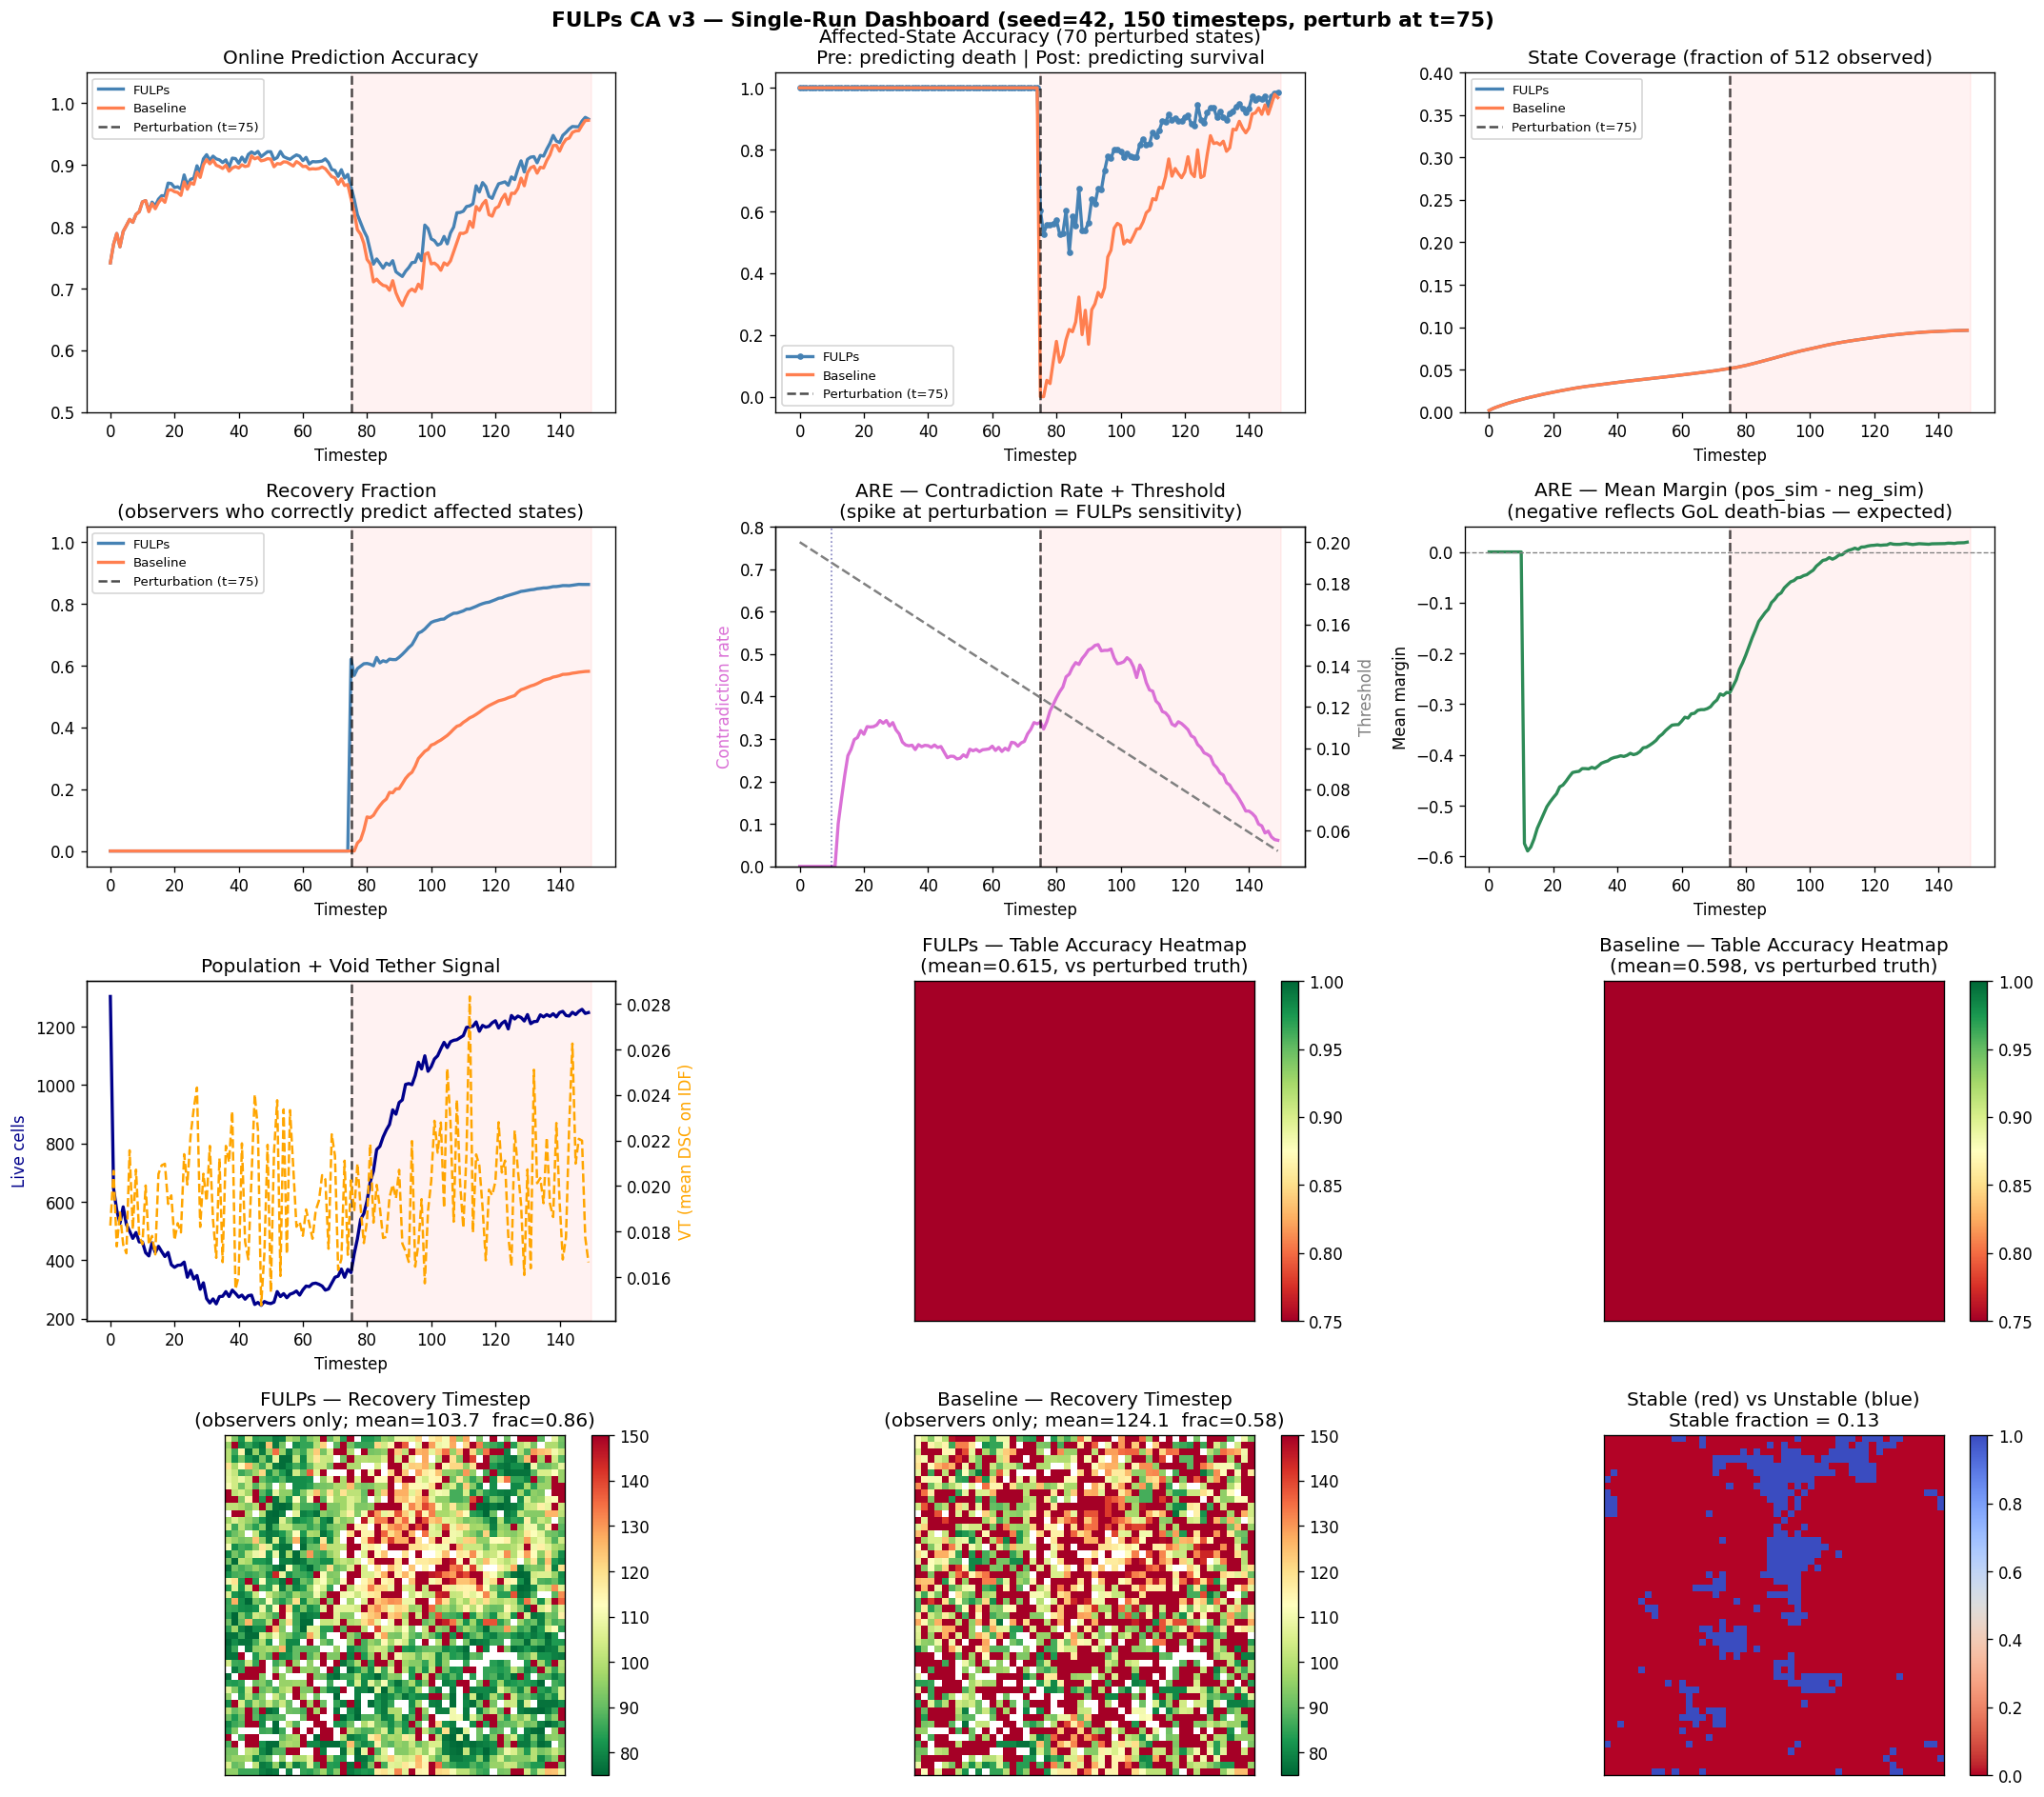

Saved: /content/fulps_ca_v3_single_run.png


In [12]:
# ── Cell 12: Single-Run Dashboard (4×3 layout) ───────────────────────────────
fig = plt.figure(figsize=(18, 16))
fig.suptitle('FULPs CA v3 — Single-Run Dashboard (seed=42, 150 timesteps, perturb at t=75)',
             fontsize=13, fontweight='bold')

T   = list(range(N_TIMESTEPS))
_vl = dict(color='black', linestyle='--', lw=1.5, alpha=0.7)  # perturbation line style

def _fill(ax):
    ax.axvspan(T_PERTURB, N_TIMESTEPS, alpha=0.05, color='red')
    ax.axvline(T_PERTURB, **_vl, label=f'Perturbation (t={T_PERTURB})')

# ── Row 1: Accuracy, Affected-state accuracy, Coverage ────────────────────────
ax1 = fig.add_subplot(4, 3, 1)
ax1.plot(T, single_history['fulps_online_acc'], color='steelblue', label='FULPs', lw=2)
ax1.plot(T, single_history['base_online_acc'],  color='coral',     label='Baseline', lw=2)
_fill(ax1)
ax1.set_title('Online Prediction Accuracy'); ax1.set_xlabel('Timestep')
ax1.set_ylim(0.5, 1.05); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(4, 3, 2)
f_aff = single_history['fulps_affected_acc']
b_aff = single_history['base_affected_acc']
f_aff_clean = [v if not np.isnan(v) else None for v in f_aff]
b_aff_clean = [v if not np.isnan(v) else None for v in b_aff]
T_aff = [t for t, v in enumerate(f_aff_clean) if v is not None]
ax2.plot(T_aff, [f_aff[t] for t in T_aff], color='steelblue', label='FULPs', lw=2, marker='.')
T_aff_b = [t for t, v in enumerate(b_aff_clean) if v is not None]
ax2.plot(T_aff_b, [b_aff[t] for t in T_aff_b], color='coral', label='Baseline', lw=2)
_fill(ax2)
ax2.set_title('Affected-State Accuracy (70 perturbed states)\nPre: predicting death | Post: predicting survival')
ax2.set_xlabel('Timestep'); ax2.set_ylim(-0.05, 1.05); ax2.legend(fontsize=8)

ax3 = fig.add_subplot(4, 3, 3)
ax3.plot(T, single_history['fulps_coverage'], color='steelblue', label='FULPs', lw=2)
ax3.plot(T, single_history['base_coverage'],  color='coral',     label='Baseline', lw=2)
_fill(ax3)
ax3.set_title('State Coverage (fraction of 512 observed)')
ax3.set_xlabel('Timestep'); ax3.set_ylim(0, 0.4); ax3.legend(fontsize=8)

# ── Row 2: Recovery fraction, ARE contradiction, margin ───────────────────────
ax4 = fig.add_subplot(4, 3, 4)
ax4.plot(T, single_history['fulps_rec_frac'], color='steelblue', label='FULPs', lw=2)
ax4.plot(T, single_history['base_rec_frac'],  color='coral',     label='Baseline', lw=2)
_fill(ax4)
ax4.set_title('Recovery Fraction\n(observers who correctly predict affected states)')
ax4.set_xlabel('Timestep'); ax4.set_ylim(-0.05, 1.05); ax4.legend(fontsize=8)

ax5 = fig.add_subplot(4, 3, 5)
ax5b = ax5.twinx()
ax5.plot(T, single_history['contra_rate'], color='orchid', lw=2, label='Contra rate')
ax5b.plot(T, single_history['threshold'], color='gray', linestyle='--', lw=1.5,
          label='Threshold')
_fill(ax5)
ax5.axvline(BUFFER_DELAY, color='navy', linestyle=':', lw=1, alpha=0.5)
ax5.set_title('ARE — Contradiction Rate + Threshold\n(spike at perturbation = FULPs sensitivity)')
ax5.set_xlabel('Timestep')
ax5.set_ylabel('Contradiction rate', color='orchid')
ax5b.set_ylabel('Threshold', color='gray')
ax5.set_ylim(0, 0.8)

ax6 = fig.add_subplot(4, 3, 6)
ax6.plot(T, single_history['margin_mean'], color='seagreen', lw=2)
ax6.axhline(0, color='gray', linestyle='--', lw=0.8)
_fill(ax6)
ax6.set_title('ARE — Mean Margin (pos_sim - neg_sim)\n'
              '(negative reflects GoL death-bias — expected)')
ax6.set_xlabel('Timestep'); ax6.set_ylabel('Mean margin')

# ── Row 3: Population/VT, table accuracy heatmaps ────────────────────────────
ax7 = fig.add_subplot(4, 3, 7)
ax7b = ax7.twinx()
ax7.plot(T, single_history['population'], color='darkblue', lw=2, label='Population')
ax7b.plot(T, single_history['vt_signal'], color='orange', linestyle='--', lw=1.5,
          label='VT signal')
_fill(ax7)
ax7.set_title('Population + Void Tether Signal')
ax7.set_xlabel('Timestep')
ax7.set_ylabel('Live cells', color='darkblue')
ax7b.set_ylabel('VT (mean DSC on IDF)', color='orange')

ax8 = fig.add_subplot(4, 3, 8)
im8 = ax8.imshow(single_final['f_tacc_g'], cmap='RdYlGn', vmin=0.75, vmax=1.0)
ax8.set_title(f'FULPs — Table Accuracy Heatmap\n(mean={single_results["fulps_final_table_acc"]:.3f}, vs perturbed truth)')
plt.colorbar(im8, ax=ax8, fraction=0.046)
ax8.set_xticks([]); ax8.set_yticks([])

ax9 = fig.add_subplot(4, 3, 9)
im9 = ax9.imshow(single_final['b_tacc_g'], cmap='RdYlGn', vmin=0.75, vmax=1.0)
ax9.set_title(f'Baseline — Table Accuracy Heatmap\n(mean={single_results["base_final_table_acc"]:.3f}, vs perturbed truth)')
plt.colorbar(im9, ax=ax9, fraction=0.046)
ax9.set_xticks([]); ax9.set_yticks([])

# ── Row 4: Recovery heatmaps and stability ────────────────────────────────────
ax10 = fig.add_subplot(4, 3, 10)
f_rec_plot = single_final['f_rec_g'].copy()
f_rec_plot[~single_final['f_obs_g']] = np.nan
im10 = ax10.imshow(f_rec_plot, cmap='RdYlGn_r', vmin=T_PERTURB, vmax=N_TIMESTEPS)
ax10.set_title(f'FULPs — Recovery Timestep\n'
               f'(observers only; mean={single_results["fulps_recovery_t"]:.1f}  '
               f'frac={single_results["fulps_recovery_fraction"]:.2f})')
plt.colorbar(im10, ax=ax10, fraction=0.046)
ax10.set_xticks([]); ax10.set_yticks([])

ax11 = fig.add_subplot(4, 3, 11)
b_rec_plot = single_final['b_rec_g'].copy()
b_rec_plot[~single_final['f_obs_g']] = np.nan
im11 = ax11.imshow(b_rec_plot, cmap='RdYlGn_r', vmin=T_PERTURB, vmax=N_TIMESTEPS)
ax11.set_title(f'Baseline — Recovery Timestep\n'
               f'(observers only; mean={single_results["base_recovery_t"]:.1f}  '
               f'frac={single_results["base_recovery_fraction"]:.2f})')
plt.colorbar(im11, ax=ax11, fraction=0.046)
ax11.set_xticks([]); ax11.set_yticks([])

ax12 = fig.add_subplot(4, 3, 12)
im12 = ax12.imshow(single_final['stable_mask'].astype(float), cmap='coolwarm_r', vmin=0, vmax=1)
ax12.set_title(f'Stable (red) vs Unstable (blue)\nStable fraction = {single_results["stable_fraction"]:.2f}')
plt.colorbar(im12, ax=ax12, fraction=0.046)
ax12.set_xticks([]); ax12.set_yticks([])

plt.tight_layout()
path = os.path.join(OUT_DIR, 'fulps_ca_v3_single_run.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

In [13]:
# ── Cell 13: Multi-Run Study (30 runs) ───────────────────────────────────────
# Confirm single-run health checks PASS before running this cell.
print('=' * 60)
print('STARTING 30-RUN STUDY (v3 — 150 timesteps, perturb at t=75)')
print('=' * 60)
print(f'Seeds: {BASE_SEED}–{BASE_SEED+N_RUNS-1}  |  Batch CSVs every {BATCH_SIZE} runs\n')

METRIC_KEYS = [
    # Accuracy
    'fulps_final_table_acc',    'base_final_table_acc',
    'fulps_final_perstate',     'base_final_perstate',
    'fulps_stable_tacc',        'base_stable_tacc',
    'fulps_unstable_tacc',      'base_unstable_tacc',
    # Coverage
    'fulps_final_coverage',     'base_final_coverage',
    'fulps_stable_coverage',    'base_stable_coverage',
    'fulps_unstable_coverage',  'base_unstable_coverage',
    # v2 convergence (retained)
    'fulps_mean_conv_t',        'base_mean_conv_t',
    'fulps_conv_fraction',      'base_conv_fraction',
    # v3 PRIMARY: recovery
    'fulps_recovery_t',         'base_recovery_t',
    'fulps_stable_recovery_t',  'base_stable_recovery_t',
    'fulps_unstable_recovery_t','base_unstable_recovery_t',
    'fulps_recovery_fraction',  'base_recovery_fraction',
    'n_affected_observers',
    # v3 ARE spike
    'contra_pre_mean',          'contra_post_mean',
    'contra_spike',
    # Summary
    'stable_fraction',          'mean_contra_rate',
]

all_results = {k: [] for k in METRIC_KEYS}
all_rows    = []

for run_idx in range(N_RUNS):
    seed = BASE_SEED + run_idx
    print(f'Run {run_idx+1:2d}/{N_RUNS}  (seed={seed})', end=' ... ')

    _, results, _ = run_simulation(
        seed=seed,
        void_model=void_model,
        idf=IDF,
        dsc_threshold=DSC_THRESHOLD,
        is_single_run=False,
        verbose=False,
    )

    for k in METRIC_KEYS:
        all_results[k].append(results.get(k, np.nan))

    row = {'run': run_idx + 1, 'seed': seed}
    row.update(results)
    all_rows.append(row)

    if (run_idx + 1) % BATCH_SIZE == 0:
        batch_num  = (run_idx + 1) // BATCH_SIZE
        batch_df   = pd.DataFrame(all_rows[-BATCH_SIZE:])
        batch_path = os.path.join(OUT_DIR, f'results_v3_batch_{batch_num}.csv')
        batch_df.to_csv(batch_path, index=False)
        f_rt = np.nanmean(all_results['fulps_recovery_t'][-BATCH_SIZE:])
        b_rt = np.nanmean(all_results['base_recovery_t'][-BATCH_SIZE:])
        spike = np.nanmean(all_results['contra_spike'][-BATCH_SIZE:])
        print(f'\n  Batch {batch_num} saved -> {batch_path}')
        print(f'  Batch mean  f_rec_t={f_rt:.1f}  b_rec_t={b_rt:.1f}  spike={spike:+.4f}')
    else:
        f_rt = results.get('fulps_recovery_t', np.nan)
        b_rt = results.get('base_recovery_t',  np.nan)
        spike = results.get('contra_spike', np.nan)
        print(f'f_rec_t={f_rt:.1f}  b_rec_t={b_rt:.1f}  spike={spike:+.4f}')

full_df   = pd.DataFrame(all_rows)
full_path = os.path.join(OUT_DIR, 'results_30runs_ca_v3.csv')
full_df.to_csv(full_path, index=False)
print(f'\nFull CSV saved -> {full_path}')
print('Download from the Colab file panel.')

STARTING 30-RUN STUDY (v3 — 150 timesteps, perturb at t=75)
Seeds: 42–71  |  Batch CSVs every 5 runs

Run  1/30  (seed=42) ... f_rec_t=103.7  b_rec_t=124.1  spike=+0.0976
Run  2/30  (seed=43) ... f_rec_t=107.4  b_rec_t=124.5  spike=+0.0129
Run  3/30  (seed=44) ... f_rec_t=108.5  b_rec_t=125.7  spike=+0.0289
Run  4/30  (seed=45) ... f_rec_t=108.2  b_rec_t=125.6  spike=+0.0407
Run  5/30  (seed=46) ... 
  Batch 1 saved -> /content/results_v3_batch_1.csv
  Batch mean  f_rec_t=107.5  b_rec_t=125.2  spike=+0.0375
Run  6/30  (seed=47) ... f_rec_t=112.9  b_rec_t=128.0  spike=+0.0558
Run  7/30  (seed=48) ... f_rec_t=103.3  b_rec_t=122.8  spike=+0.0928
Run  8/30  (seed=49) ... f_rec_t=100.8  b_rec_t=123.7  spike=+0.0354
Run  9/30  (seed=50) ... f_rec_t=104.8  b_rec_t=124.5  spike=+0.0177
Run 10/30  (seed=51) ... 
  Batch 2 saved -> /content/results_v3_batch_2.csv
  Batch mean  f_rec_t=105.8  b_rec_t=124.8  spike=+0.0479
Run 11/30  (seed=52) ... f_rec_t=107.2  b_rec_t=125.1  spike=+0.0622
Run 12/

In [14]:
# ── Cell 14: Statistical Summary ─────────────────────────────────────────────
print('=' * 60)
print('30-RUN STATISTICAL SUMMARY — FULPs CA v3')
print('=' * 60)


def summarise(key):
    a = np.array([v for v in all_results[key] if not np.isnan(v)])
    if len(a) == 0: return np.nan, np.nan, np.nan
    ci = 1.96 * a.std() / np.sqrt(len(a))
    return a.mean(), a.std(), ci


def safe_arr(key):
    return np.array([v for v in all_results[key] if not np.isnan(v)])


def cohens_d(a, b):
    pooled = np.sqrt((a.std() ** 2 + b.std() ** 2) / 2)
    return (a.mean() - b.mean()) / pooled if pooled > 1e-9 else np.nan


print(f"\n  {'Metric':<36} {'Mean':>7} {'SD':>7} {'95% CI':>10}")
print('  ' + '-' * 64)
for k in METRIC_KEYS:
    m, s, ci = summarise(k)
    if not np.isnan(m):
        print(f'  {k:<36} {m:>7.3f} {s:>7.3f}  +-{ci:>6.3f}')


print('\n── PRIMARY HYPOTHESIS TESTS ───────────────────────────────')

# PRIMARY Hyp A: ARE contradiction spike positive (paired)
pre_m  = safe_arr('contra_pre_mean')
post_m = safe_arr('contra_post_mean')
spike_a = safe_arr('contra_spike')
if len(spike_a) > 2:
    t_sp, p_sp = stats.ttest_1samp(spike_a, 0)
    print(f'\n  Hyp A — Contradiction spike > 0 (one-sample t vs 0)')
    print(f'    pre mean={pre_m.mean():.3f}  post mean={post_m.mean():.3f}')
    print(f'    spike mean={spike_a.mean():.4f}  t={t_sp:.3f}  p={p_sp:.4f}')
    print(f'    -> {"SUPPORTED" if p_sp < 0.05 and spike_a.mean() > 0 else "NOT SUPPORTED"}')

# PRIMARY Hyp B: FULPs recovery faster than baseline (paired t-test)
f_rt = safe_arr('fulps_recovery_t')
b_rt = safe_arr('base_recovery_t')
if len(f_rt) > 2 and len(b_rt) > 2:
    t_rt, p_rt = stats.ttest_rel(f_rt, b_rt)
    d_rt = cohens_d(f_rt, b_rt)
    wins = (safe_arr('fulps_recovery_t') < safe_arr('base_recovery_t')).sum()
    print(f'\n  Hyp B — FULPs vs Baseline recovery timestep (paired)')
    print(f'    FULPs mean={f_rt.mean():.2f}  Baseline mean={b_rt.mean():.2f}')
    print(f'    t={t_rt:.3f}  p={p_rt:.4f}  Cohen d={d_rt:.3f}')
    print(f'    FULPs faster in {wins}/{len(f_rt)} runs')
    print(f'    -> {"SUPPORTED" if p_rt < 0.05 and f_rt.mean() < b_rt.mean() else "NOT SUPPORTED"}')

# Recovery by region
f_srt = safe_arr('fulps_stable_recovery_t')
f_urt = safe_arr('fulps_unstable_recovery_t')
if len(f_srt) > 2 and len(f_urt) > 2:
    t_reg, p_reg = stats.ttest_ind(f_srt, f_urt)
    print(f'\n  Recovery by region (FULPs): stable vs unstable')
    print(f'    stable mean={f_srt.mean():.2f}  unstable mean={f_urt.mean():.2f}')
    print(f'    t={t_reg:.3f}  p={p_reg:.4f}')

# Overall table accuracy (retained from v2)
f_tacc = safe_arr('fulps_final_table_acc')
b_tacc = safe_arr('base_final_table_acc')
if len(f_tacc) > 2:
    t_main, p_main = stats.ttest_rel(f_tacc, b_tacc)
    d_main = cohens_d(f_tacc, b_tacc)
    wins_t = (f_tacc > b_tacc).sum()
    print(f'\n  Overall table accuracy — FULPs vs Baseline (retained from v2)')
    print(f'    FULPs mean={f_tacc.mean():.4f}  Baseline mean={b_tacc.mean():.4f}')
    print(f'    t={t_main:.3f}  p={p_main:.4f}  Cohen d={d_main:.3f}')
    print(f'    FULPs wins: {wins_t}/{len(f_tacc)}')

# Per-state accuracy
f_ps = safe_arr('fulps_final_perstate')
b_ps = safe_arr('base_final_perstate')
if len(f_ps) > 2:
    t_ps, p_ps = stats.ttest_rel(f_ps, b_ps)
    d_ps = cohens_d(f_ps, b_ps)
    print(f'\n  Per-state accuracy — FULPs vs Baseline (retained from v2)')
    print(f'    FULPs mean={f_ps.mean():.4f}  Baseline mean={b_ps.mean():.4f}')
    print(f'    t={t_ps:.3f}  p={p_ps:.4f}  Cohen d={d_ps:.3f}')

30-RUN STATISTICAL SUMMARY — FULPs CA v3

  Metric                                  Mean      SD     95% CI
  ----------------------------------------------------------------
  fulps_final_table_acc                  0.614   0.002  +- 0.001
  base_final_table_acc                   0.598   0.001  +- 0.000
  fulps_final_perstate                   0.814   0.008  +- 0.003
  base_final_perstate                    0.664   0.004  +- 0.001
  fulps_stable_tacc                      0.598   0.001  +- 0.000
  base_stable_tacc                       0.595   0.000  +- 0.000
  fulps_unstable_tacc                    0.617   0.002  +- 0.001
  base_unstable_tacc                     0.599   0.000  +- 0.000
  fulps_final_coverage                   0.099   0.005  +- 0.002
  base_final_coverage                    0.099   0.005  +- 0.002
  fulps_stable_coverage                  0.056   0.004  +- 0.001
  base_stable_coverage                   0.056   0.004  +- 0.001
  fulps_unstable_coverage                0.10

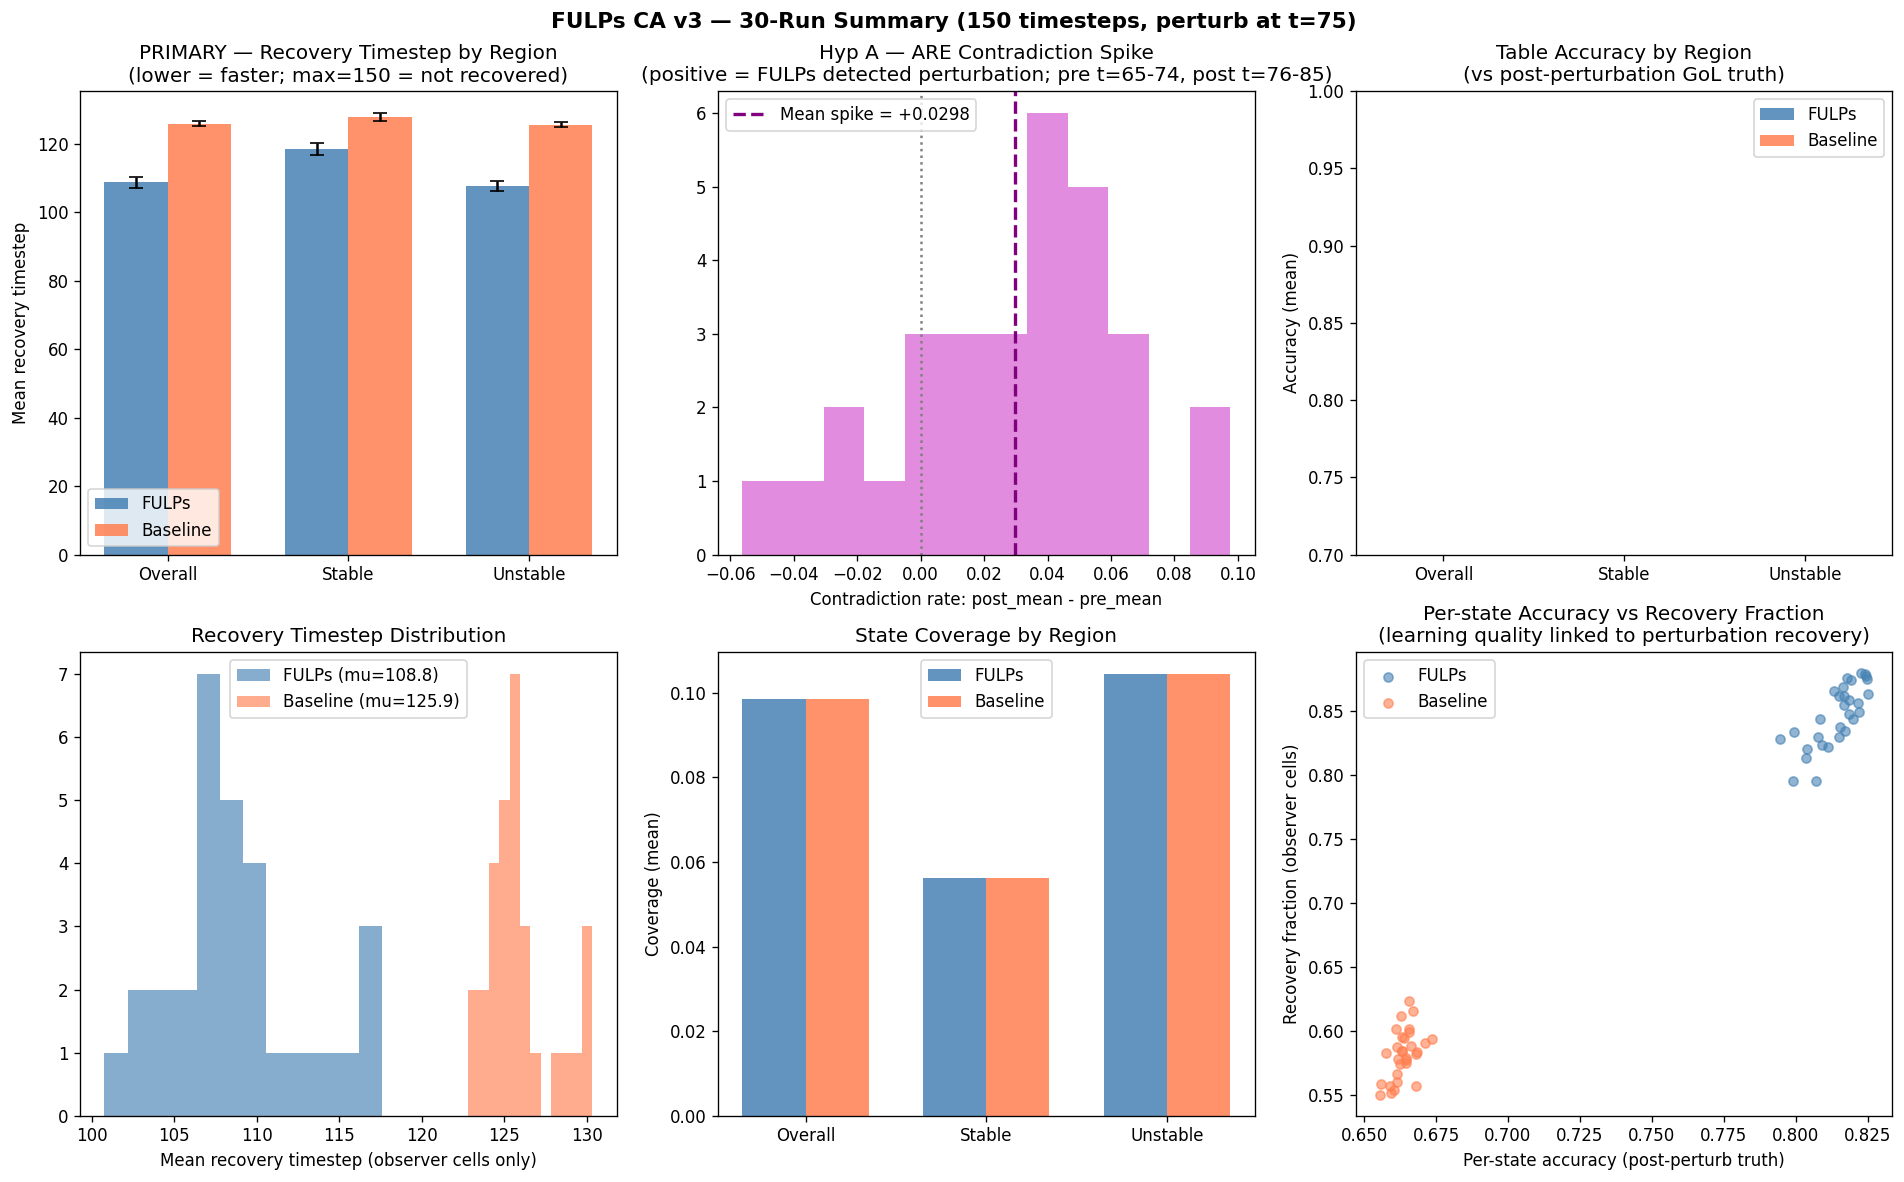

Multi-run chart saved -> /content/fulps_ca_v3_multirun.png
Full CSV              -> /content/results_30runs_ca_v3.csv
Download both from the Colab file panel.


In [15]:
# ── Cell 15: Multi-Run Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('FULPs CA v3 — 30-Run Summary (150 timesteps, perturb at t=75)',
             fontsize=13, fontweight='bold')

def safe_mean(key):  return np.nanmean(all_results[key])
def safe_ci(key):    return 1.96 * np.nanstd(all_results[key]) / np.sqrt(N_RUNS)
def safe_arr_v(key): return np.array([v for v in all_results[key] if not np.isnan(v)])

# ── PRIMARY: Recovery timestep by region ──────────────────────────────────────
ax = axes[0, 0]
cats     = ['Overall', 'Stable', 'Unstable']
f_rt_bar = [safe_mean('fulps_recovery_t'),         safe_mean('fulps_stable_recovery_t'),
            safe_mean('fulps_unstable_recovery_t')]
b_rt_bar = [safe_mean('base_recovery_t'),          safe_mean('base_stable_recovery_t'),
            safe_mean('base_unstable_recovery_t')]
f_ci_rt  = [safe_ci('fulps_recovery_t'),           safe_ci('fulps_stable_recovery_t'),
            safe_ci('fulps_unstable_recovery_t')]
b_ci_rt  = [safe_ci('base_recovery_t'),            safe_ci('base_stable_recovery_t'),
            safe_ci('base_unstable_recovery_t')]
x, w     = np.arange(3), 0.35
ax.bar(x - w/2, f_rt_bar, w, yerr=f_ci_rt, capsize=4, label='FULPs',    color='steelblue', alpha=0.85)
ax.bar(x + w/2, b_rt_bar, w, yerr=b_ci_rt, capsize=4, label='Baseline', color='coral',     alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_title('PRIMARY — Recovery Timestep by Region\n(lower = faster; max=150 = not recovered)')
ax.set_ylabel('Mean recovery timestep'); ax.legend()

# ── Contradiction spike distribution ─────────────────────────────────────────
ax = axes[0, 1]
spikes = safe_arr_v('contra_spike')
if len(spikes) > 0:
    ax.hist(spikes, bins=12, color='orchid', alpha=0.8)
    ax.axvline(spikes.mean(), color='purple', linestyle='--', lw=2,
               label=f'Mean spike = {spikes.mean():+.4f}')
    ax.axvline(0, color='gray', linestyle=':', lw=1.5)
ax.set_xlabel('Contradiction rate: post_mean - pre_mean')
ax.set_title('Hyp A — ARE Contradiction Spike\n'
             f'(positive = FULPs detected perturbation; pre t={SPIKE_PRE_START}-{SPIKE_PRE_END-1}, '
             f'post t={SPIKE_POST_START}-{SPIKE_POST_END-1})')
ax.legend()

# ── Table accuracy by region ──────────────────────────────────────────────────
ax = axes[0, 2]
f_ta  = [safe_mean('fulps_final_table_acc'), safe_mean('fulps_stable_tacc'),
         safe_mean('fulps_unstable_tacc')]
b_ta  = [safe_mean('base_final_table_acc'),  safe_mean('base_stable_tacc'),
         safe_mean('base_unstable_tacc')]
ax.bar(x - w/2, f_ta, w, label='FULPs',    color='steelblue', alpha=0.85)
ax.bar(x + w/2, b_ta, w, label='Baseline', color='coral',     alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylim(0.7, 1.0)
ax.set_title('Table Accuracy by Region\n(vs post-perturbation GoL truth)')
ax.set_ylabel('Accuracy (mean)'); ax.legend()

# ── Recovery timestep distribution ───────────────────────────────────────────
ax = axes[1, 0]
f_rtv = safe_arr_v('fulps_recovery_t')
b_rtv = safe_arr_v('base_recovery_t')
if len(f_rtv) > 0:
    ax.hist(f_rtv, bins=12, alpha=0.65, color='steelblue',
            label=f'FULPs (mu={f_rtv.mean():.1f})')
if len(b_rtv) > 0:
    ax.hist(b_rtv, bins=12, alpha=0.65, color='coral',
            label=f'Baseline (mu={b_rtv.mean():.1f})')
ax.set_xlabel('Mean recovery timestep (observer cells only)')
ax.set_title('Recovery Timestep Distribution')
ax.legend()

# ── Coverage by region ────────────────────────────────────────────────────────
ax = axes[1, 1]
f_cv  = [safe_mean('fulps_final_coverage'),   safe_mean('fulps_stable_coverage'),
         safe_mean('fulps_unstable_coverage')]
b_cv  = [safe_mean('base_final_coverage'),    safe_mean('base_stable_coverage'),
         safe_mean('base_unstable_coverage')]
ax.bar(x - w/2, f_cv, w, label='FULPs',    color='steelblue', alpha=0.85)
ax.bar(x + w/2, b_cv, w, label='Baseline', color='coral',     alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_title('State Coverage by Region'); ax.set_ylabel('Coverage (mean)')
ax.legend()

# ── Per-state accuracy vs recovery fraction scatter ───────────────────────────
ax = axes[1, 2]
for k_ps, k_rf, col, lbl in [
    ('fulps_final_perstate', 'fulps_recovery_fraction', 'steelblue', 'FULPs'),
    ('base_final_perstate',  'base_recovery_fraction',  'coral',     'Baseline'),
]:
    xv = np.array(all_results[k_ps])
    yv = np.array(all_results[k_rf])
    mask = ~(np.isnan(xv) | np.isnan(yv))
    ax.scatter(xv[mask], yv[mask], color=col, alpha=0.6, s=30, label=lbl)
ax.set_xlabel('Per-state accuracy (post-perturb truth)')
ax.set_ylabel('Recovery fraction (observer cells)')
ax.set_title('Per-state Accuracy vs Recovery Fraction\n'
             '(learning quality linked to perturbation recovery)')
ax.legend()

plt.tight_layout()
mr_path = os.path.join(OUT_DIR, 'fulps_ca_v3_multirun.png')
plt.savefig(mr_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Multi-run chart saved -> {mr_path}')
print(f'Full CSV              -> {full_path}')
print('Download both from the Colab file panel.')

Corr(contradiction, online gain) = 0.7913
Corr(contradiction, table gain)  = 0.2723


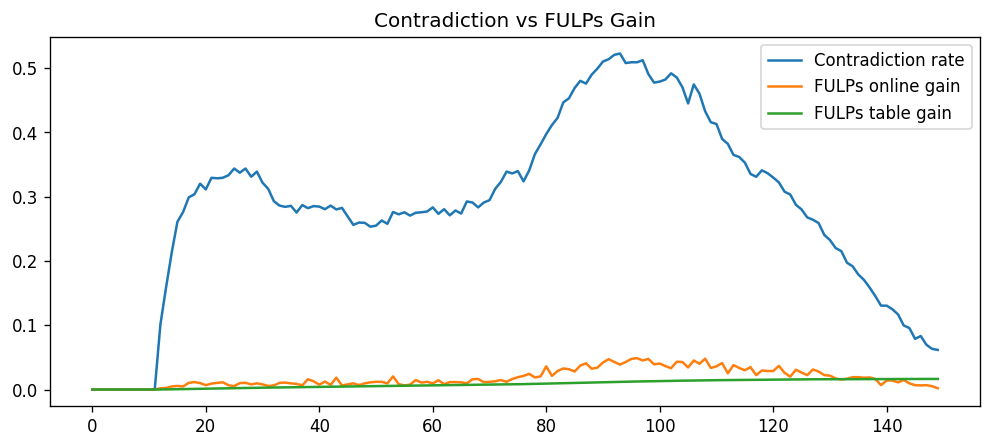

In [16]:
# ── Cell 16: Contradiction Diagnostics ─────────────────────────────────────────
contra = np.array(single_history['contra_rate'])

delta_online = np.array(single_history['fulps_online_acc']) - np.array(single_history['base_online_acc'])
delta_table  = np.array(single_history['fulps_table_acc'])  - np.array(single_history['base_table_acc'])

corr_online = np.corrcoef(contra, delta_online)[0,1]
corr_table  = np.corrcoef(contra, delta_table)[0,1]

print(f"Corr(contradiction, online gain) = {corr_online:.4f}")
print(f"Corr(contradiction, table gain)  = {corr_table:.4f}")

plt.figure(figsize=(10,4))
plt.plot(contra, label='Contradiction rate')
plt.plot(delta_online, label='FULPs online gain')
plt.plot(delta_table, label='FULPs table gain')
plt.legend()
plt.title("Contradiction vs FULPs Gain")
plt.show()